In [ ]:
import cv2
import matplotlib.pyplot as plt

# convert to bgr -> rgb
def load_image(path):
    img = cv2.imread(path)                      # loads as BGR
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert to RGB right away

# display images back to back w/ titles
def show(images, titles=None, size=5):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(size * n, size))
    if n == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)  # masks show in grayscale
        ax.set_title(titles[i] if titles else "")
        ax.axis("off")
    #plt.tight_layout()
    plt.show()

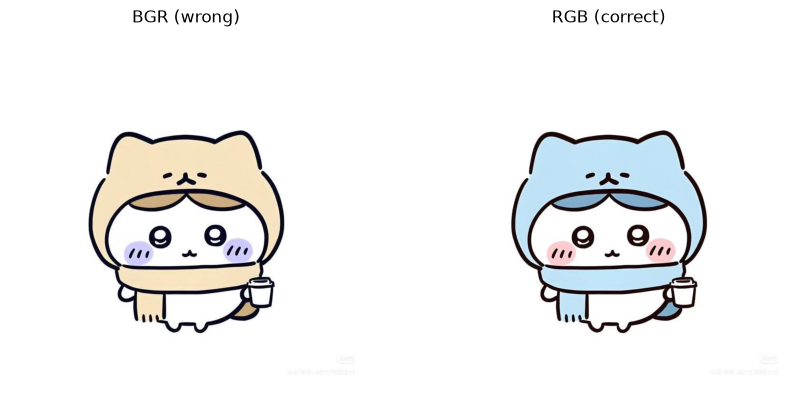

In [ ]:
# compare bgr vs. rgb
bgr = cv2.imread("/Users/bianca/Documents/gen-plush/data/test_images/2d/hard/3h.jpg")  # no conversion
rgb = load_image("/Users/bianca/Documents/gen-plush/data/test_images/2d/hard/3h.jpg")
show([bgr, rgb], ["BGR (wrong)", "RGB (correct)"])

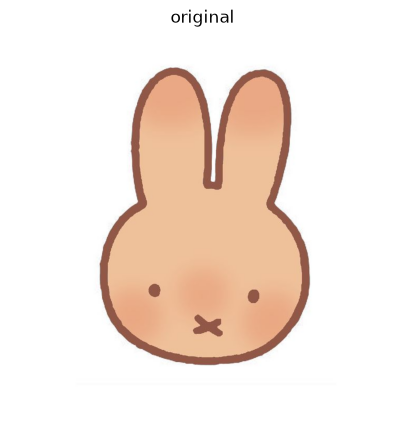

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


In [15]:
img = load_image("/Users/bianca/Documents/gen-plush/data/test_images/2d/easy/1e.jpg")
show([img], ["original"])
print(img)

In [17]:
height, width, channels = img.shape

In [18]:
print(height)
print(width)
print(channels)

736
736
3


In [ ]:
# normalize image widths/lengths to 1024px (if too big)
def resize_longest(img, max_side=1024, allow_upscale=False):
    h, w = img.shape[:2]
    longest = max(h, w)
    scale = max_side / longest
    if scale > 1 and not allow_upscale:
        return img, 1.0  # already small enough, leave it alone
    new_w = round(w * scale)
    new_h = round(h * scale)
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)
    return resized, scale

from pathlib import Path
root = Path("/Users/bianca/Documents/gen-plush/data/test_images/2d")
extensions = {".png", ".jpg", ".jpeg", ".webp"}
images = {}

# apply resizing to all images
for path in sorted(root.rglob("*")):
    # check if it's even an image
    if path.suffix.lower() not in extensions:
        continue
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    # do nothing if no path
    if img is None:
        continue
    # resize image
    resized, scale = resize_longest(img)
    images[f"{path.parent.name}/{path.name}"] = resized

    # prints image name, shape, and the scale
    print(f"{path.name}: {img.shape[1]}x{img.shape[0]} -> {resized.shape[1]}x{resized.shape[0]} (scale {scale:.2f})")

1e.jpg: 736x736 -> 736x736 (scale 1.00)
2e.jpg: 380x400 -> 380x400 (scale 1.00)
3e.jpg: 1080x1080 -> 1024x1024 (scale 0.95)
4e.jpg: 828x835 -> 828x835 (scale 1.00)
5e.jpg: 736x736 -> 736x736 (scale 1.00)
6e.jpg: 1000x1000 -> 1000x1000 (scale 1.00)
1h.jpg: 1024x1024 -> 1024x1024 (scale 1.00)
2h.jpg: 736x736 -> 736x736 (scale 1.00)
3h.jpg: 736x736 -> 736x736 (scale 1.00)
4h.jpg: 736x1104 -> 683x1024 (scale 0.93)
5h.jpg: 736x736 -> 736x736 (scale 1.00)
6h.jpg: 736x977 -> 736x977 (scale 1.00)
1m.jpg: 960x960 -> 960x960 (scale 1.00)
2m.jpg: 736x784 -> 736x784 (scale 1.00)
3m.jpg: 518x396 -> 518x396 (scale 1.00)
4m.jpg: 500x500 -> 500x500 (scale 1.00)
5m.jpg: 497x461 -> 497x461 (scale 1.00)
6m.png: 1152x2048 -> 576x1024 (scale 0.50)


In [28]:
# display all images
def load_all(root, max_side=1024):
    extensions = {".png", ".jpg", ".jpeg", ".webp"}
    imgs, titles, scales = [], [], []
    for path in sorted(root.rglob("*")):
        if path.suffix.lower() not in extensions:
            continue
        img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"Couldn't read: {path}")
            continue
        resized, scale = resize_longest(img, max_side)
        if resized.ndim == 3 and resized.shape[2] == 4:
            resized = cv2.cvtColor(resized, cv2.COLOR_BGRA2RGBA)  # keep transparency
        else:
            resized = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        imgs.append(resized)
        titles.append(str(path.relative_to(root)))
        scales.append(scale)
    return imgs, titles, scales

In [29]:
imgs, titles, scales = load_all(root)

In [30]:
import math

def show_grid(images, titles=None, cols=4, size=4):
    rows = math.ceil(len(images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < len(images):
            img = images[i]
            ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
            ax.set_title(titles[i] if titles else "", fontsize=9)
    plt.tight_layout()
    plt.show()

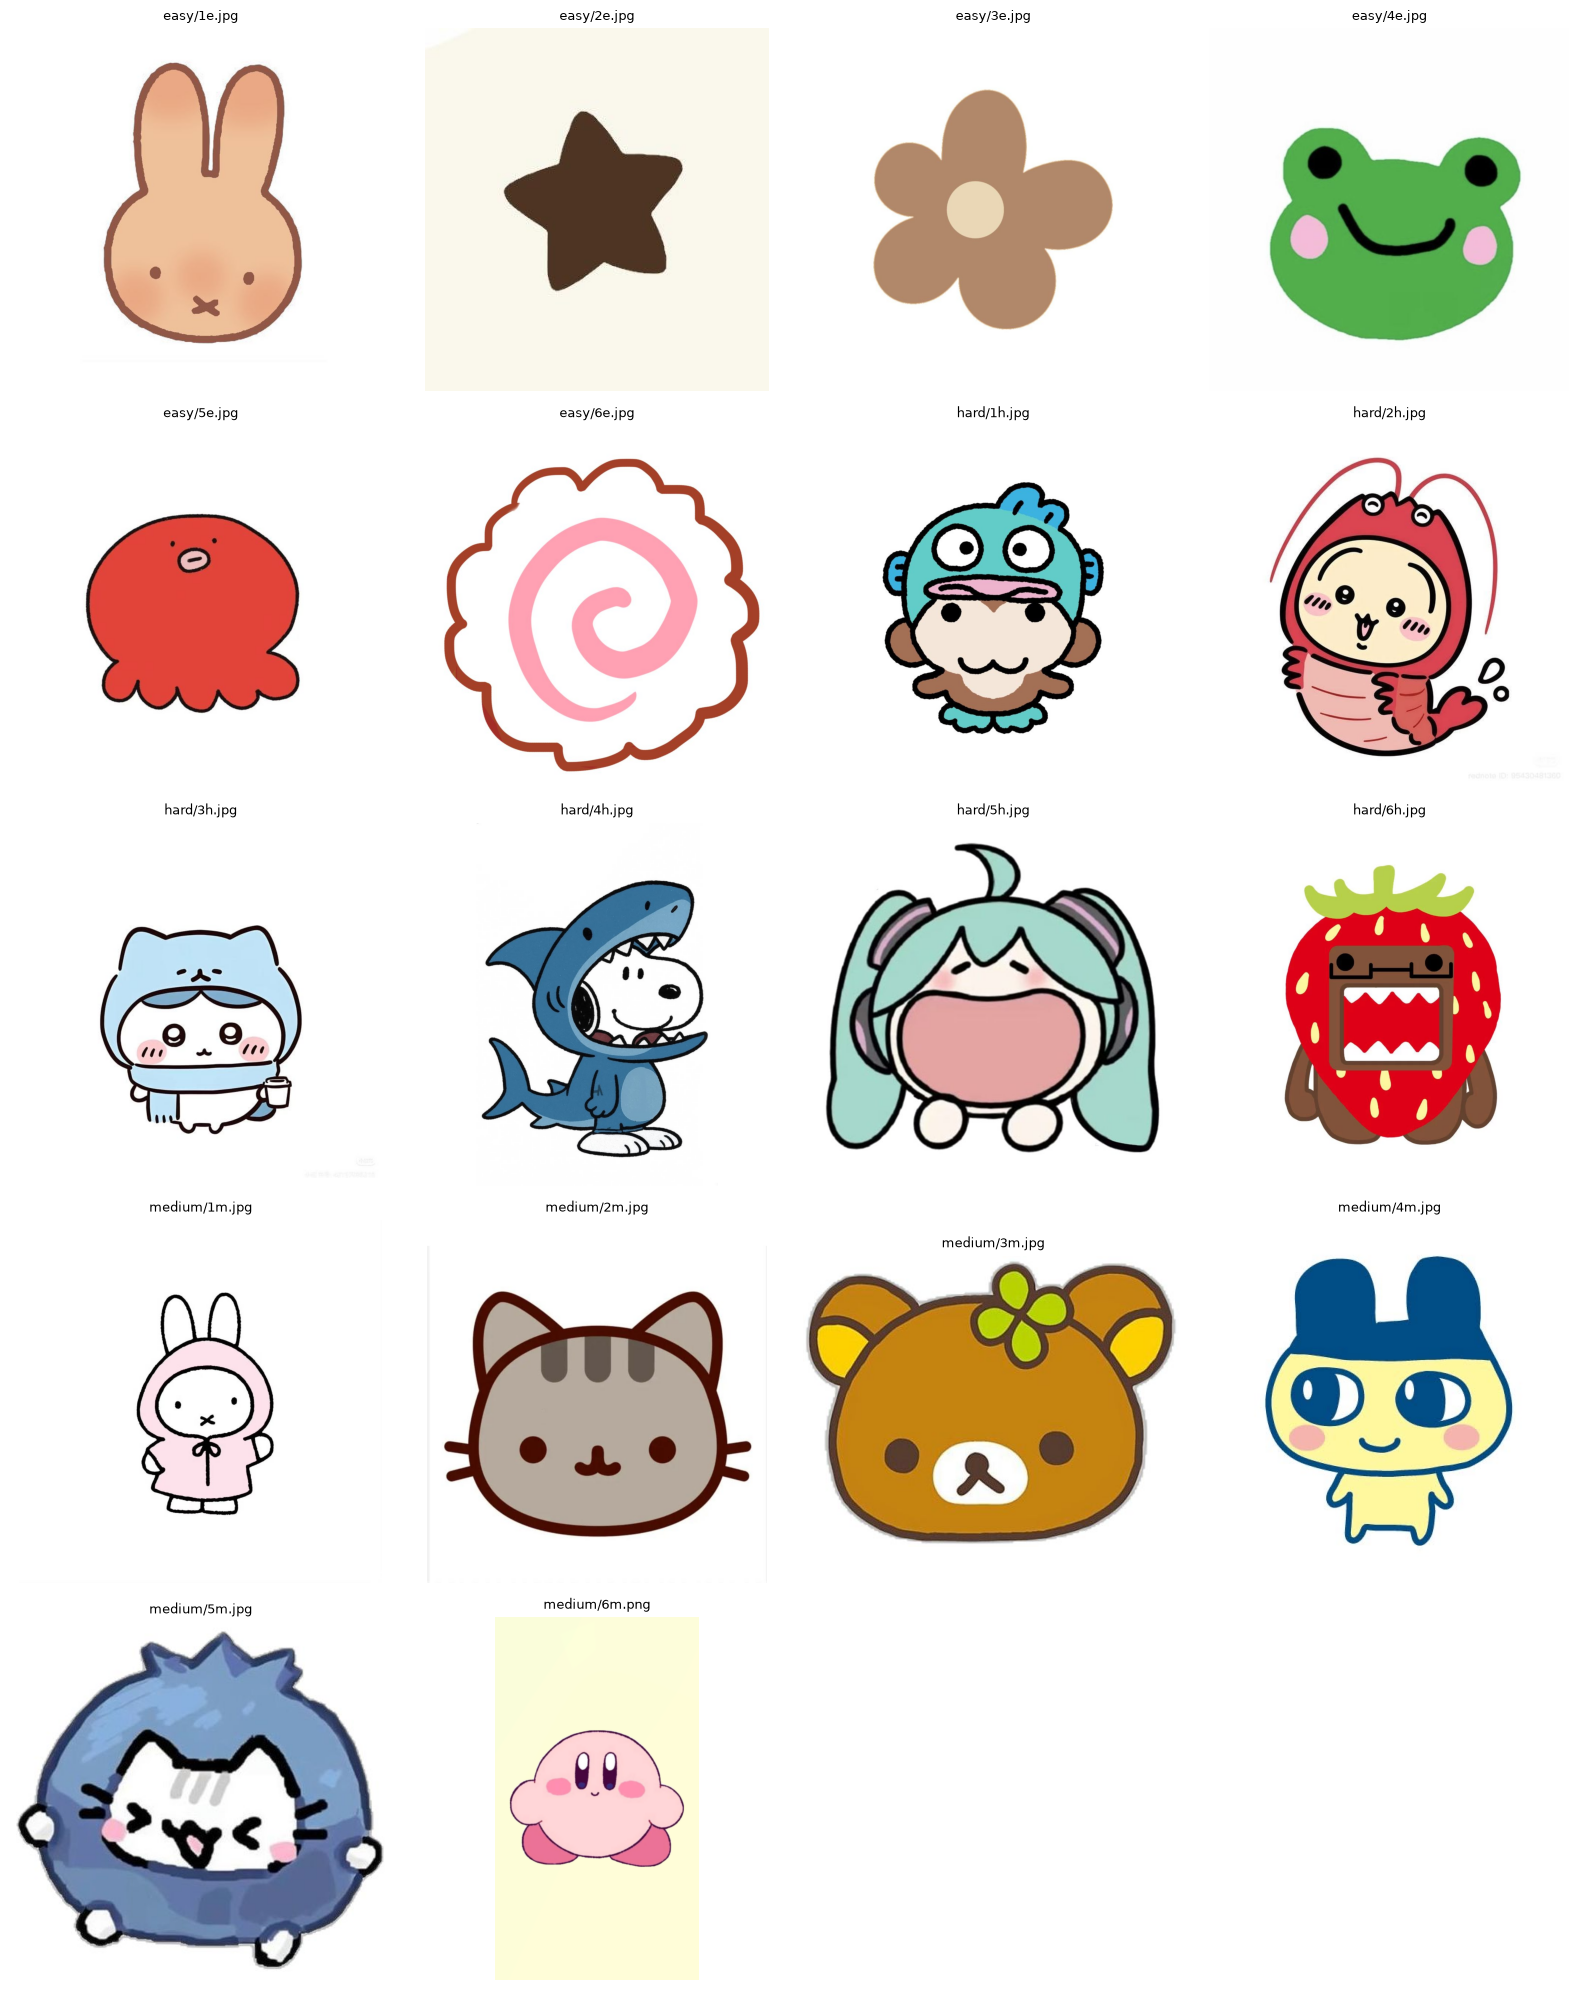

In [31]:
show_grid(imgs, titles)

In [4]:
# remove background of a single image: 1e.jpg
from pathlib import Path
from rembg import remove
from PIL import Image

root = Path("/Users/bianca/Documents/gen-plush/data/test_images/2d")
out_dir = Path("/Users/bianca/Documents/gen-plush/data/2d-cleaned")
out_dir.mkdir(parents=True, exist_ok=True)  # creates the folder if it doesn't exist

img = Image.open(root / "easy" / "1e.jpg")
output = remove(img)
output.save(out_dir / "1e_r.png")

KeyboardInterrupt: 

In [6]:
from rembg import remove, new_session

root = Path("/Users/bianca/Documents/gen-plush/data/test_images/2d")
out_root = Path("/Users/bianca/Documents/gen-plush/data/2d-cleaned/2d_nobg")
extensions = {".png", ".jpg", ".jpeg", ".webp"}

session = new_session("isnet-anime")  # load the model once, reuse for every image

for path in sorted(root.rglob("*")):
    if path.suffix.lower() not in extensions:
        continue
    out_path = out_root / path.relative_to(root).with_suffix(".png")
    if out_path.exists():
        continue  # skip images already processed
    out_path.parent.mkdir(parents=True, exist_ok=True)

    img = Image.open(path)
    img.thumbnail((1024, 1024))  # first-stage resize: longest side 1024, never upscales
    output = remove(img, session=session)
    output.save(out_path)
    print(f"Done: {path.relative_to(root)}")

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

Done: easy/1e.jpg
Done: easy/2e.jpg
Done: easy/3e.jpg
Done: easy/4e.jpg
Done: easy/5e.jpg
Done: easy/6e.jpg
Done: hard/1h.jpg
Done: hard/2h.jpg
Done: hard/3h.jpg
Done: hard/4h.jpg
Done: hard/5h.jpg
Done: hard/6h.jpg
Done: medium/1m.jpg
Done: medium/2m.jpg
Done: medium/3m.jpg
Done: medium/4m.jpg
Done: medium/5m.jpg
Done: medium/6m.png


In [1]:
import sys
print(sys.executable)
import onnxruntime
print(onnxruntime.__version__)

/Users/bianca/Documents/gen-plush/.venv/bin/python
1.30.0


In [5]:
%pip install onnxruntime "rembg[cpu]"

  Using cached onnxruntime-1.30.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (5.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 30.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [onnxruntime] [onnxruntime]
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install "rembg[cpu]"

Note: you may need to restart the kernel to use updated packages.
